# Miscellaneous Analyses

## Purpose: 

This is meant for mini-analyses and questions that need answered that don't fall into the normal workflow. 

## Packages and Options

In [1]:
import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import glob, pickle, seaborn  
import matplotlib.pyplot as plt

import networkx

## Confirm that the relative scores from `JASPAR 2022` are ranks

In [2]:
rank_observation_num_differences = []

for file in glob.glob("2_get_data/outputs/*"): 
    
    tmp_df = pd.read_csv(file, sep="\t", header=None)
    tmp_df = tmp_df[[4]]
        
    if tmp_df[4].min()!=800: 
        "Min not 800 {}".format(file)
        tmp_df[4].min()
        
    if tmp_df[4].max()!=1000: 
        "Max not 1000 {}".format(file)
        tmp_df[4].max()
    
    rank_observation_num_differences.append(
        
            (tmp_df[tmp_df[4]<900].index.size) - (tmp_df[tmp_df[4]>900].index.size)
        
    )

'Max not 1000 2_get_data/outputs/MA1114.1.tsv'

998

<Figure size 960x720 with 0 Axes>

<Axes: >

Text(0.5, 0.98, 'Difference Between Number of JASPAR \n Predictions with Relative Score < 900 and > 900 \n 24 dots correspond to 24 TFs and ideally this should be 24 zeros')

(-0.1, 0.1)

Text(0.5, 56.283333333333324, 'Absolute Value Difference')

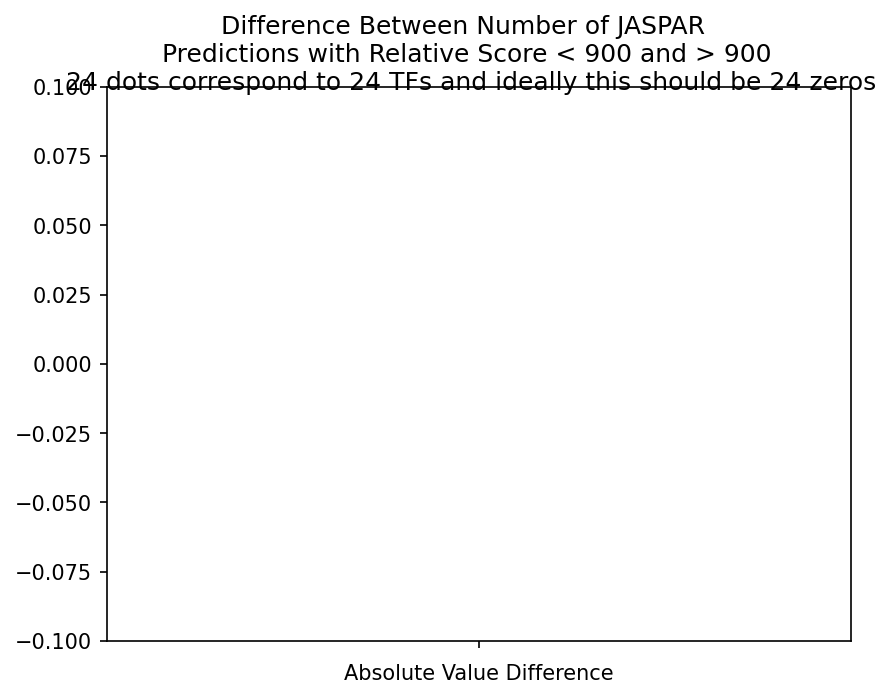

In [3]:
plt.figure(dpi=150)

seaborn.swarmplot(rank_observation_num_differences)

plt.suptitle("Difference Between Number of JASPAR \n Predictions with Relative Score < 900 and > 900 \n 24 dots correspond to 24 TFs and ideally this should be 24 zeros")

plt.ylim(-0.1, 0.1)

plt.xlabel("Absolute Value Difference")

Oh no!!! Looks like they're not ranks as we expected. 

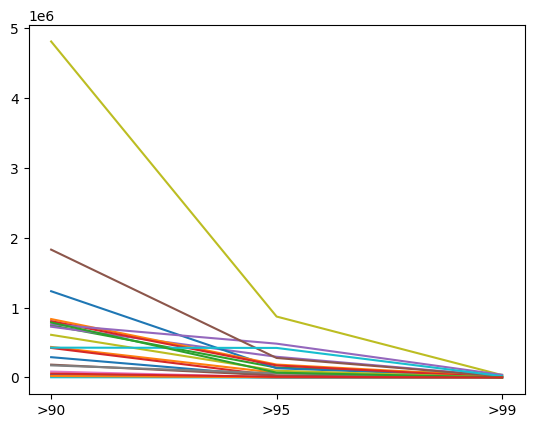

In [4]:
labels=[">90", ">95", ">99"]


for file in glob.glob("2_get_data/outputs/*"): 
    
    tmp_df = pd.read_csv(file, sep="\t", header=None)
    tmp_df = tmp_df[[4]]
    
    line = [tmp_df[tmp_df[4]>900].index.size, tmp_df[tmp_df[4]>950].index.size, tmp_df[tmp_df[4]>990].index.size]
    
    plt.plot(labels, line)

plt.show()

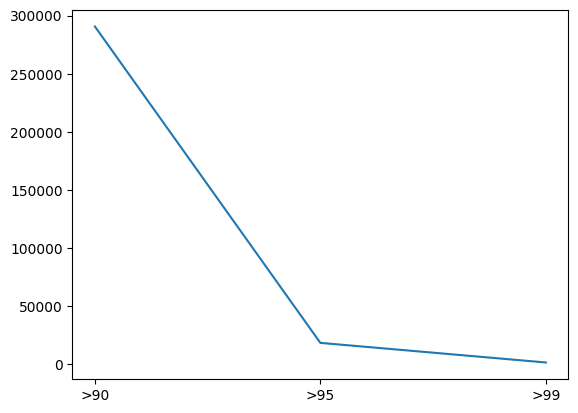

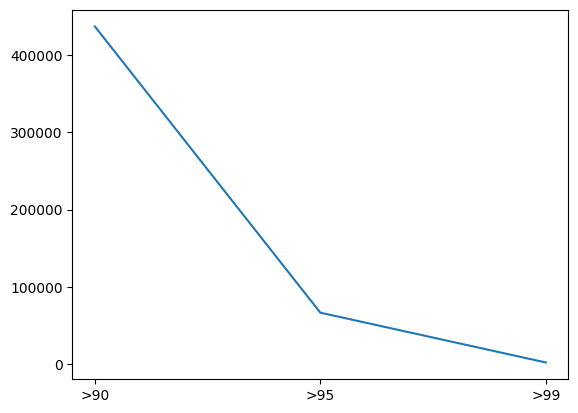

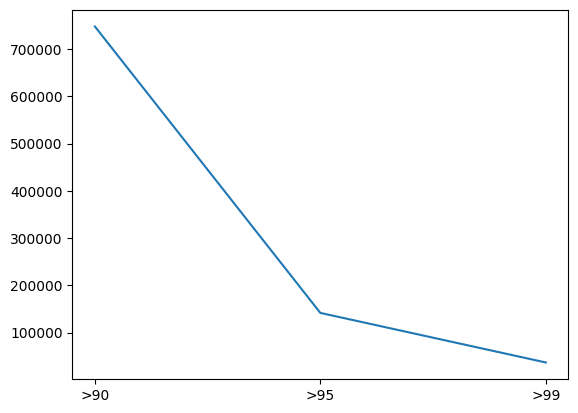

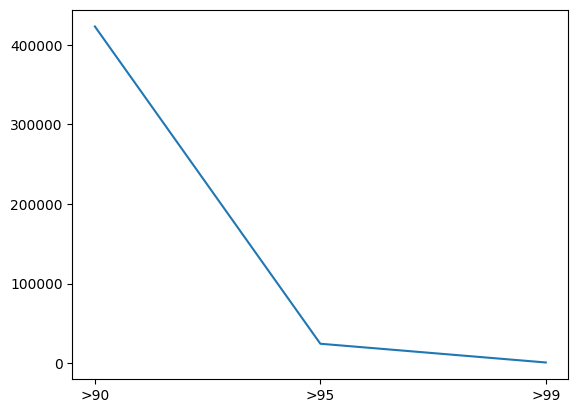

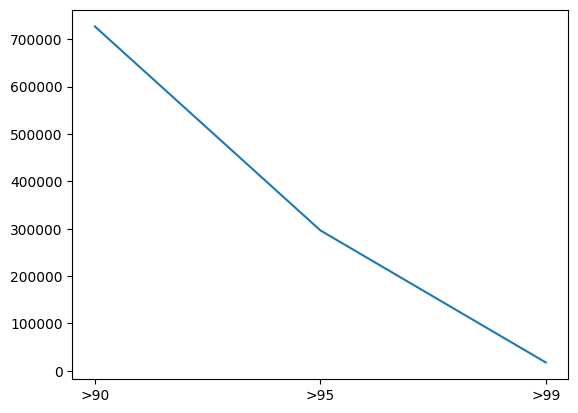

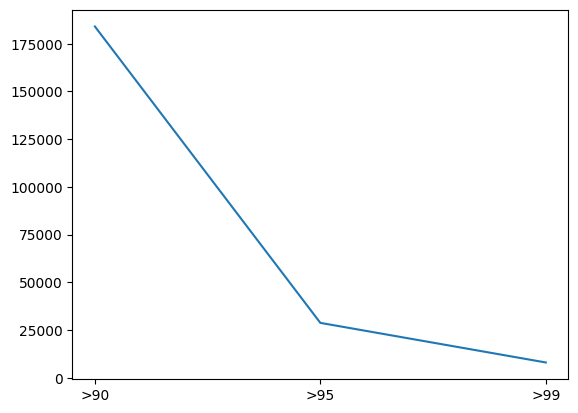

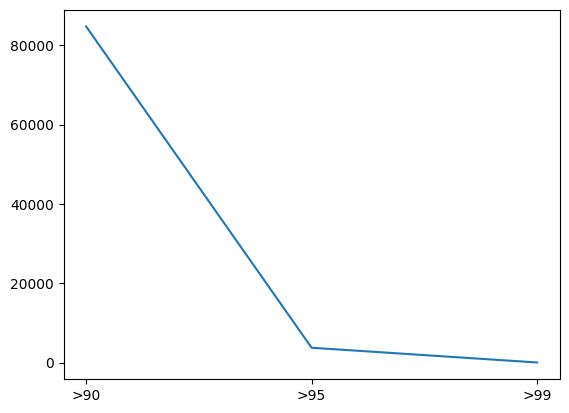

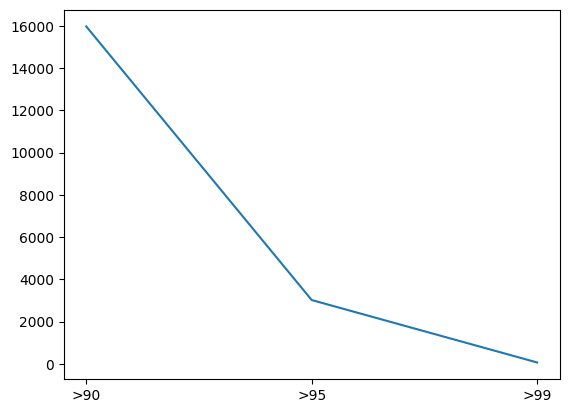

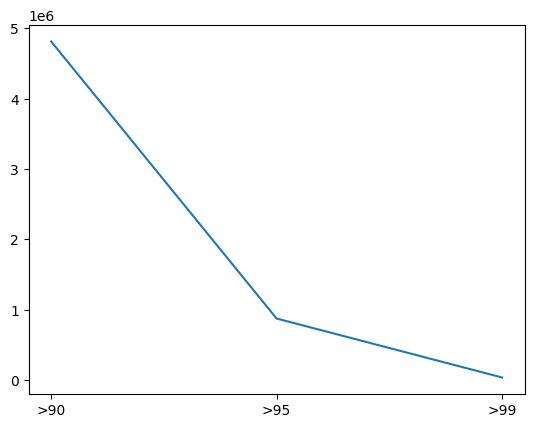

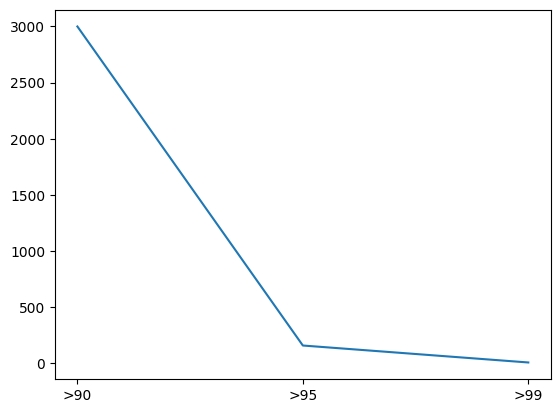

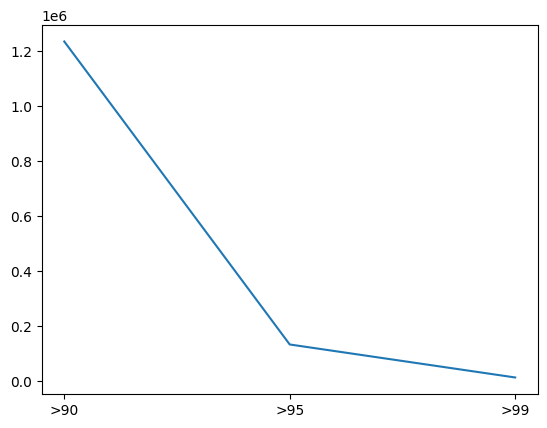

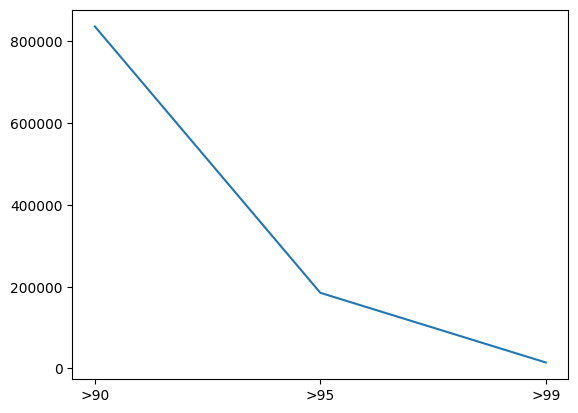

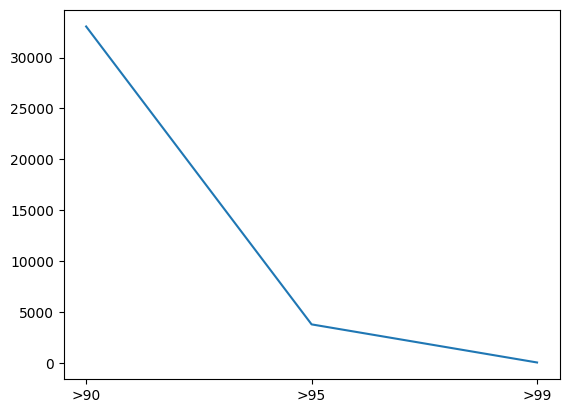

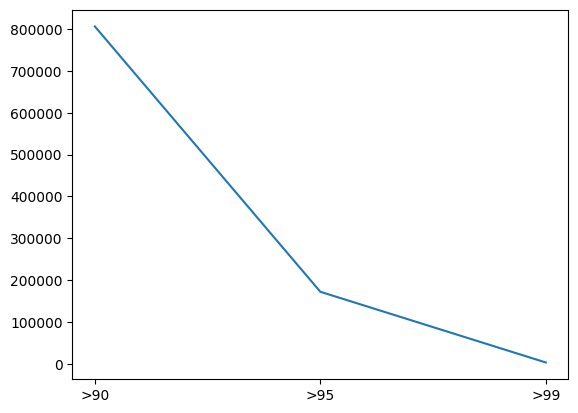

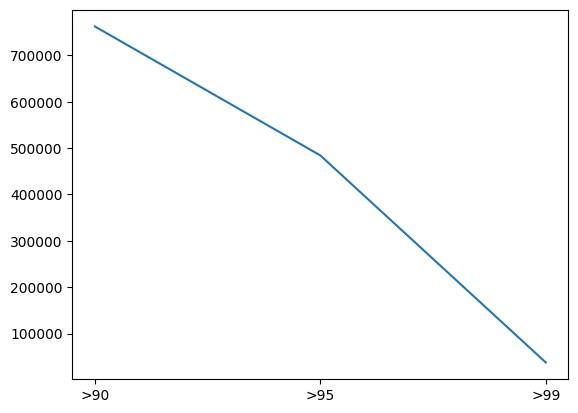

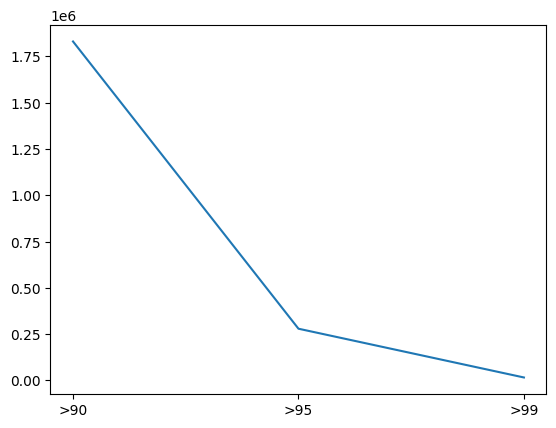

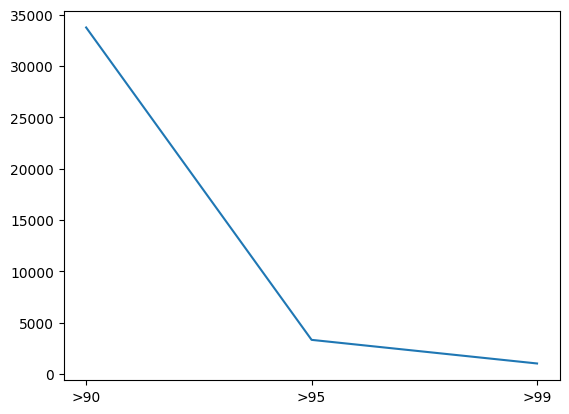

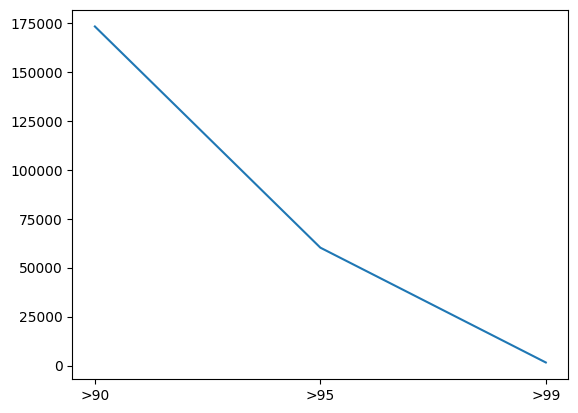

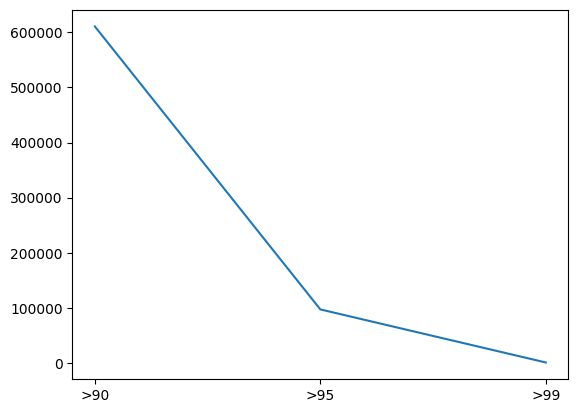

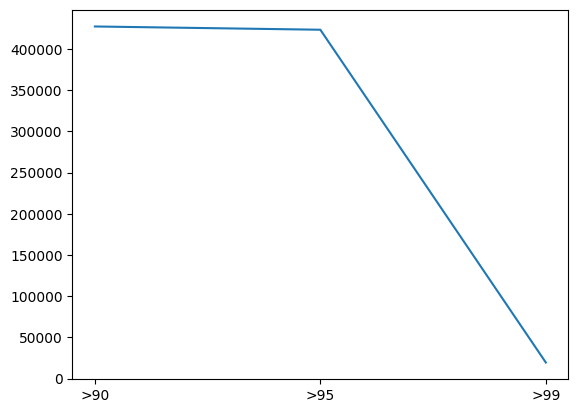

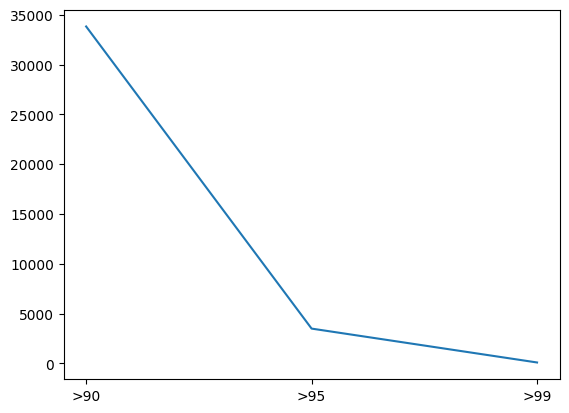

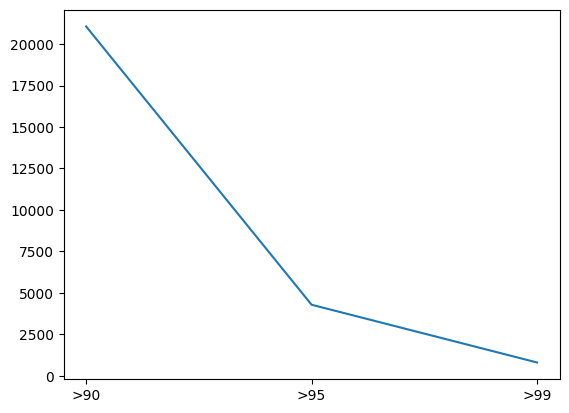

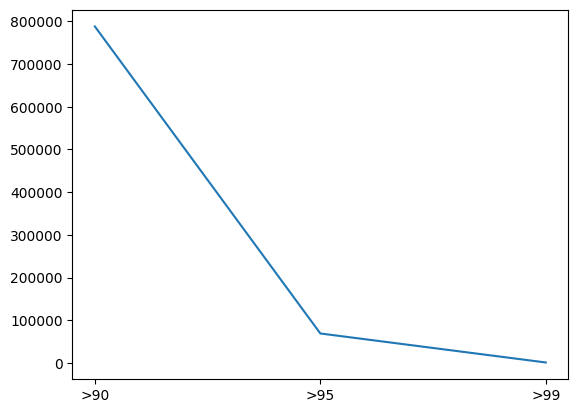

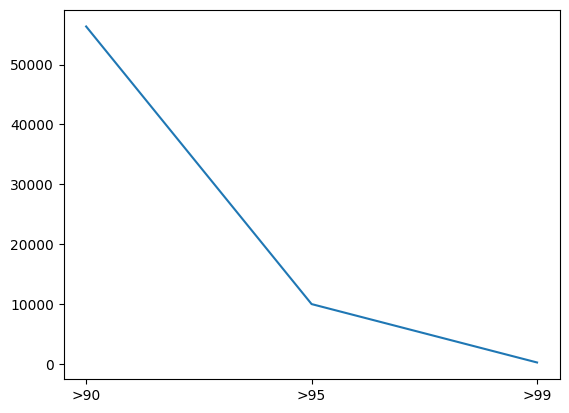

In [5]:
labels=[">90", ">95", ">99"]


for file in glob.glob("2_get_data/outputs/*"): 
    
    tmp_df = pd.read_csv(file, sep="\t", header=None)
    tmp_df = tmp_df[[4]]
    
    line = [tmp_df[tmp_df[4]>900].index.size, tmp_df[tmp_df[4]>950].index.size, tmp_df[tmp_df[4]>990].index.size]
    
    plt.plot(labels, line)
    
    plt.show()

## Load Differential Expression Genes-TF Networks

In [6]:
files = glob.glob("../../outputs/pickled_networks/differential_expression_tf_networks/*")

files

['../../outputs/pickled_networks/differential_expression_tf_networks/upstream_5000_score_990.networkx_graph',
 '../../outputs/pickled_networks/differential_expression_tf_networks/upstream_2500_score_950.networkx_graph',
 '../../outputs/pickled_networks/differential_expression_tf_networks/upstream_750_score_900.networkx_graph',
 '../../outputs/pickled_networks/differential_expression_tf_networks/upstream_5000_score_950.networkx_graph',
 '../../outputs/pickled_networks/differential_expression_tf_networks/upstream_2500_score_990.networkx_graph',
 '../../outputs/pickled_networks/differential_expression_tf_networks/upstream_5000_score_900.networkx_graph',
 '../../outputs/pickled_networks/differential_expression_tf_networks/upstream_750_score_990.networkx_graph',
 '../../outputs/pickled_networks/differential_expression_tf_networks/upstream_750_score_950.networkx_graph',
 '../../outputs/pickled_networks/differential_expression_tf_networks/upstream_2500_score_900.networkx_graph']

In [7]:
diff_expression_tf_networks = {}

for file in files:
    
    parameter_combination = file.split("/")[-1].split(".")[0]
    diff_expression_tf_networks[parameter_combination] = pickle.load(open(file, 'rb'))
    
    

In [8]:
for key in diff_expression_tf_networks: 
    diff_expression_tf_networks[key]

## Retrieve the following summary statistics for each parameter combination:
* Total nodes in network
* Number of "TFs of interest" from Muge (out of 24)
* Weak and strong connected components: 
    * Number of nodes in each type

In [9]:
# initialize all the lists 
parameter_combinations = []
total_nodes = []
tfs_of_interest = []
num_strongly_connected_components = []
num_weakly_connected_components = []
num_nodes_strongly_connected_components = []
num_nodes_weakly_connected_components=[]

for key in diff_expression_tf_networks: 
    
    tmp = diff_expression_tf_networks[key]
    
    parameter_combinations.append(key)
    
    total_nodes.append(tmp.number_of_nodes())
    
    candidate_tf_list = []
    
    for edge in tmp.edges(): 
        candidate_tf_list.append(edge[0])
    
    tfs_of_interest = len(set(candidate_tf_list))
    
    num_strongly_connected_components.append(networkx.number_strongly_connected_components(tmp))
    num_weakly_connected_components.append(networkx.number_weakly_connected_components(tmp))
    

In [10]:
summary = pd.DataFrame(
    {
        "Parameter Combination": parameter_combinations,
        "Total Nodes in Network": total_nodes, 
        "TFs from Muge (24 total)": tfs_of_interest, 
        "Number of Strongly Connected Components": num_strongly_connected_components, 
        "Number of Weakly Connected Components": num_weakly_connected_components, 
        
    }, 
)

summary = summary.sort_values(["Parameter Combination"])

summary

,Parameter Combination,Total Nodes in Network,TFs from Muge (24 total),Number of Strongly Connected Components,Number of Weakly Connected Components
8,upstream_2500_score_900,325,24,317,1
1,upstream_2500_score_950,324,24,321,1
4,upstream_2500_score_990,207,24,207,1
5,upstream_5000_score_900,325,24,316,1
3,upstream_5000_score_950,325,24,317,1
0,upstream_5000_score_990,248,24,247,1
2,upstream_750_score_900,324,24,317,1
7,upstream_750_score_950,312,24,311,1
6,upstream_750_score_990,143,24,143,1


In [ ]:
# summary.to_csv("/home/jve4pt/network_summary_stats.tsv", sep="\t")

## Understand Modularity Scores Across `Louvain` Clusterings

In [11]:
pandas_dict = {}

for file in glob.glob("../../outputs/pickled_networks/differential_expression_tf_networks/*"): 
    
    key = file.split("/")[-1].split(".")[0].split("_")[1] + "-" + file.split("/")[-1].split(".")[0].split("_")[3]
    key 
    
    pandas_dict[key] = {"Modularity":[]}
    
    tmp_network = pickle.load(open(file, "rb"))
    
    for iteration in range(1000): 
        pandas_dict[key]["Modularity"].append(
            
            networkx.community.modularity(
            
                tmp_network, 
                networkx.community.louvain_communities(
                    tmp_network, 
                )
            )
        )
        

'5000-990'

'2500-950'

'750-900'

'5000-950'

'2500-990'

'5000-900'

'750-990'

'750-950'

'2500-900'

In [12]:
combination_order = pd.api.types.CategoricalDtype(
    [
        "750-900",
        "750-950",
        "750-990",
        "2500-900",
        "2500-950",
        "2500-990",
        "5000-900",
        "5000-950",
        "5000-990"
    ], 
    ordered=True
)

In [13]:
modularity_df = pd.DataFrame.from_dict(pandas_dict).stack().explode().reset_index().set_index("level_0")

modularity_df["level_1"] = modularity_df["level_1"].astype(combination_order)

modularity_df = modularity_df.sort_values("level_1")

modularity_df.columns=["Parameter Combination", "Modularity"]

modularity_df.head()

,Parameter Combination,Modularity
level_0,,
Modularity,750-900,0.107733
Modularity,750-900,0.10826
Modularity,750-900,0.114333
Modularity,750-900,0.109479
Modularity,750-900,0.113067


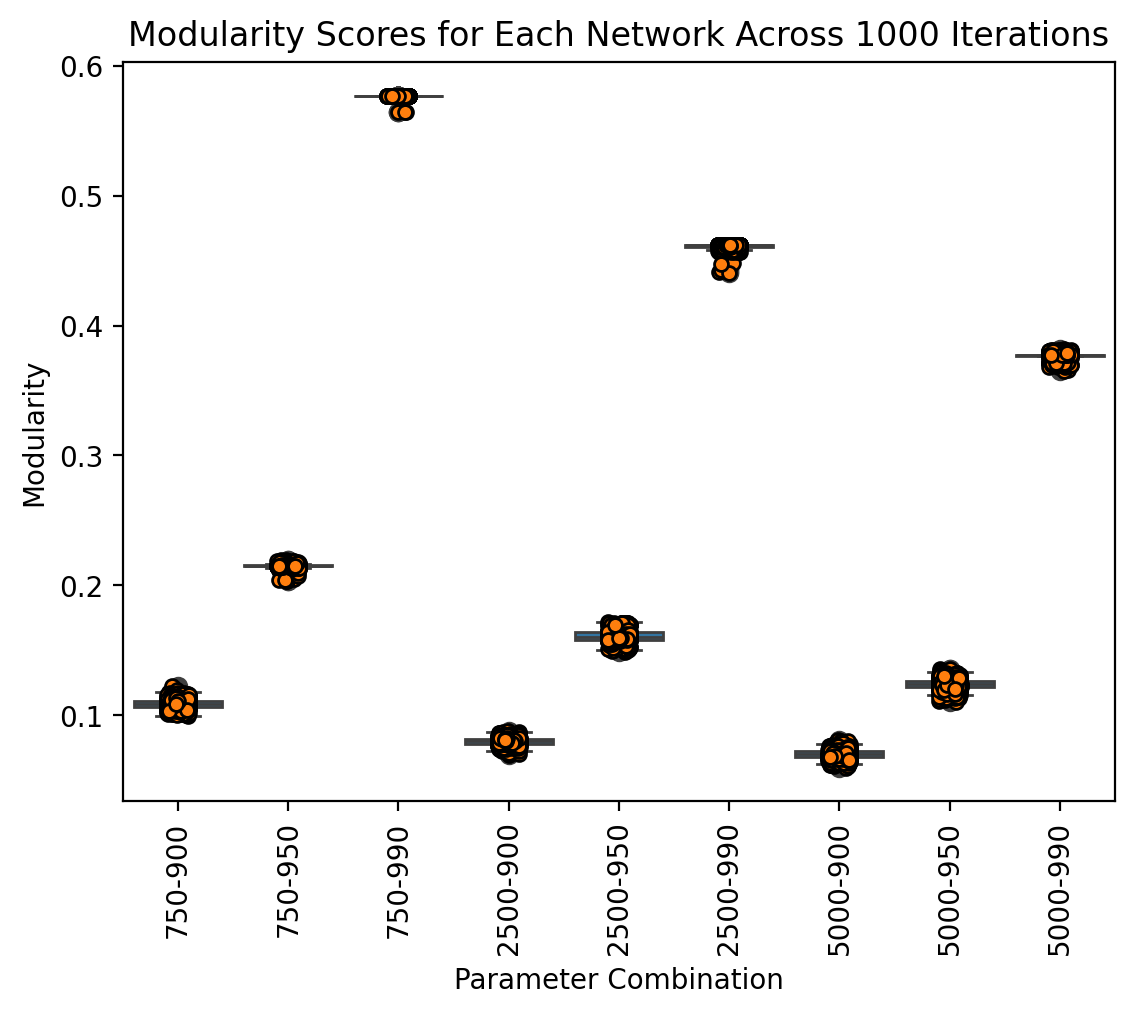

In [14]:
_=plt.figure(dpi=200)
_=plt.title("Modularity Scores for Each Network Across 1000 Iterations")
_=seaborn.boxplot(x="Parameter Combination", y="Modularity", data=modularity_df)
_=seaborn.stripplot(x="Parameter Combination", y="Modularity", data=modularity_df, edgecolor="black", linewidth=1)
_=plt.xticks(rotation=90)


## Group TFs and Targets for `Upstream 750` and `Rel Score > 950` (Sunny's Request)

In [15]:
tmp = pickle.load(
    open(
       "../../outputs/pickled_networks/differential_expression_tf_networks/upstream_750_score_950.networkx_graph", 
        "rb"
    )
)


pd.DataFrame(tmp.edges(), columns=["TF", "Target"]).to_csv("upstream_TSS_750_score_950_all_TF_targets.csv", index=False)

tmp = pd.DataFrame(tmp.edges(), columns=["TF", "Target"])

In [16]:
pd.DataFrame(tmp.groupby("Target")["TF"].apply(lambda x: ", ".join(x))).to_csv("upstream_TSS_750_score_950_targets_grouped_by_all_TFs.csv")

## Number of TFs bound per Diff. Exp. Gene per Param Combo 

In [18]:
final_df = pd.DataFrame()

for key in sorted(list(diff_expression_tf_networks)):
    tmp_df = networkx.to_pandas_edgelist(diff_expression_tf_networks[key])

    tmp_df = tmp_df.groupby("target").count().rename(columns={"source": key})

    final_df = final_df.join(tmp_df, how="outer")

final_df = final_df.sort_index().fillna(0).astype(int).reset_index().rename(columns={"target": "Differentially Expressed Gene"})
final_df

final_df.to_csv("diff_exp_genes_by_num_tfs_per_param_combo_january_25_2025.tsv", sep="\t", index=False)

,Differentially Expressed Gene,upstream_2500_score_900,upstream_2500_score_950,upstream_2500_score_990,upstream_5000_score_900,upstream_5000_score_950,upstream_5000_score_990,upstream_750_score_900,upstream_750_score_950,upstream_750_score_990
0,2310030g06rik,11,5,1,13,7,2,7,0,0
1,2810459m11rik,14,7,1,17,8,1,8,2,0
2,abca1,19,15,7,20,17,7,18,12,6
3,abcc5,18,12,2,19,14,3,18,12,1
4,abhd18,15,10,2,17,14,2,9,5,1
5,acly,16,10,0,17,11,3,10,7,0
6,acta1,13,8,1,14,8,1,10,6,0
7,actg1,12,8,0,14,8,0,11,7,0
8,actn2,17,11,2,20,12,3,15,7,1
9,adam33,17,9,1,18,10,1,11,6,1
